Importing libraries

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Importing dataset

In [21]:
dataset = pd.read_csv('WSN-DS[1].csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values
feature_names = dataset.columns[1:-1].tolist()  # Convert column names to a list
feature_names = np.array(feature_names)


In [22]:
print(X)
print(y)
print(feature_names)

[[5.0000000e+01 1.0000000e+00 1.0100000e+05 ... 1.3008535e+02
  0.0000000e+00 2.4694000e+00]
 [5.0000000e+01 0.0000000e+00 1.0104400e+05 ... 0.0000000e+00
  4.0000000e+00 6.9570000e-02]
 [5.0000000e+01 0.0000000e+00 1.0101000e+05 ... 0.0000000e+00
  3.0000000e+00 6.8980000e-02]
 ...
 [1.0030000e+03 0.0000000e+00 2.0109500e+05 ... 1.3926438e+02
  1.0000000e+00 9.4370000e-02]
 [1.0030000e+03 0.0000000e+00 2.0105100e+05 ... 1.5827492e+02
  3.0000000e+00 1.6047000e-01]
 [1.0250000e+03 0.0000000e+00 2.0210000e+05 ... 1.1500407e+02
  0.0000000e+00 1.0132500e+00]]
['Normal' 'Normal' 'Normal' ... 'Normal' 'Normal' 'Normal']
[' Time' ' Is_CH' ' who CH' ' Dist_To_CH' ' ADV_S' ' ADV_R' ' JOIN_S'
 ' JOIN_R' ' SCH_S' ' SCH_R' 'Rank' ' DATA_S' ' DATA_R' ' Data_Sent_To_BS'
 ' dist_CH_To_BS' ' send_code ' 'Expaned Energy']


Missind Data

In [23]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(X[:, 1:-1])
X[:, 1:-1] = imputer.transform(X[:, 1:-1])

Encoding categorical data

In [24]:
#from sklearn.compose import ColumnTransformer
#from sklearn.preprocessing import OneHotEncoder
#ct = ColumnTransformer(transformers=[
 #   ('encoder', OneHotEncoder(), [0])
#], remainder='passthrough')

#y = (ct.fit_transform(y.reshape(-1, 1)))
#print(y)#


Splitting dataset into training and test set

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

Selecting best features

             Feature    Importance
2             who CH  9.250403e+09
0               Time  2.927490e+07
12            DATA_R  8.351680e+06
8              SCH_S  3.777392e+06
14     dist_CH_To_BS  2.997729e+06
4              ADV_S  2.884400e+06
7             JOIN_R  1.774704e+06
11            DATA_S  1.329477e+06
13   Data_Sent_To_BS  1.163185e+06
3         Dist_To_CH  6.663000e+05
5              ADV_R  5.109403e+05
10              Rank  2.815252e+05
1              Is_CH  2.002469e+05
15        send_code   7.387423e+04
6             JOIN_S  2.300798e+04
9              SCH_R  2.058400e+04
16    Expaned Energy  9.658370e+03


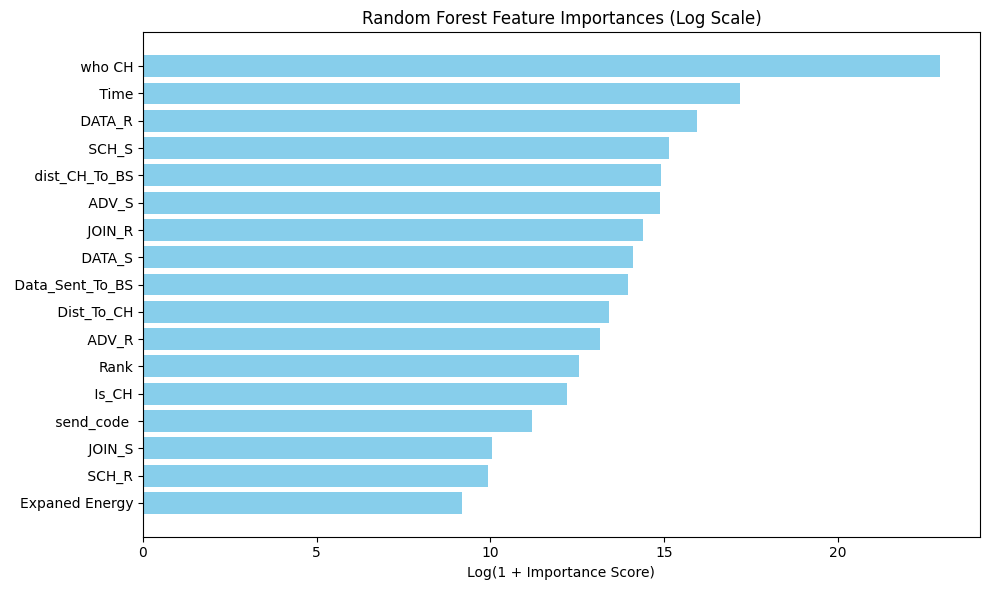

In [40]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

chi2_selector = SelectKBest(chi2, k=8)  # Set k to the desired number of features
X_train_selected = chi2_selector.fit_transform(X_train, y_train)
X_test_selected = chi2_selector.transform(X_test)

# Step 4: Display Chi-Square scores for each feature
chi_scores = chi2_selector.scores_  # Chi-Square scores for each feature
# Assign chi_scores to importances
importances = chi_scores
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Print top features
print(importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], np.log1p(importance_df['Importance']), color='skyblue')
plt.xlabel('Log(1 + Importance Score)')
plt.title('Random Forest Feature Importances (Log Scale)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Applying feature scaling

In [27]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_selected = sc.fit_transform(X_train_selected)
X_test_selected = sc.transform(X_test_selected)

In [28]:
print(X_train_selected)

[[-0.12462633 -0.40000554 -0.13087518 ... -0.30242212 -0.32062248
  -0.44891742]
 [-0.40232106 -0.41279217 -0.13087518 ...  0.00302336 -0.32062248
  -0.44891742]
 [-0.95771052 -0.43832958 -0.13087518 ...  1.36578014 -0.32062248
  -0.44891742]
 ...
 [-1.12432736 -0.4459186  -0.13087518 ... -0.09095986 -0.32062248
  -0.44891742]
 [ 0.04199051 -0.18734142 -0.13087518 ... -0.06746406 -0.32062248
  -0.44891742]
 [-0.40232106 -0.4127256  -0.13087518 ... -0.06746406 -0.32062248
  -0.44891742]]


In [29]:
print(X_test_selected)

[[ 1.09723049  0.07643848 -0.13087518 ... -0.65485922 -0.32062248
  -0.44891742]
 [-0.34678211 -0.41013959 -0.13087518 ... -0.34941374 -0.32062248
  -0.44891742]
 [-0.95771052 -0.43826045 -0.13087518 ...  0.40245207 -0.32062248
  -0.44891742]
 ...
 [-0.23570422 -0.40488822 -0.13087518 ...  1.76520885 -0.32062248
  -0.44891742]
 [ 0.1530684  -0.18232816 -0.13087518 ...  0.94285562 -0.32062248
  -0.44891742]
 [ 2.76339888  1.0980809  -0.13087518 ...  1.76520885 -0.32062248
  -0.44891742]]


KNN

In [30]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
classifier.fit(X_train_selected, y_train)

KNeighborsClassifier()

In [31]:
y_pred = classifier.predict(X_test_selected)

Accuracy

In [32]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9858540295997757


Classification Report

In [33]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Blackhole       0.99      0.99      0.99      2055
    Flooding       0.92      0.96      0.94       661
    Grayhole       0.86      0.84      0.85      2945
      Normal       0.99      0.99      0.99     67908
        TDMA       0.98      0.90      0.94      1364

    accuracy                           0.99     74933
   macro avg       0.95      0.94      0.94     74933
weighted avg       0.99      0.99      0.99     74933



Confusion Matrix

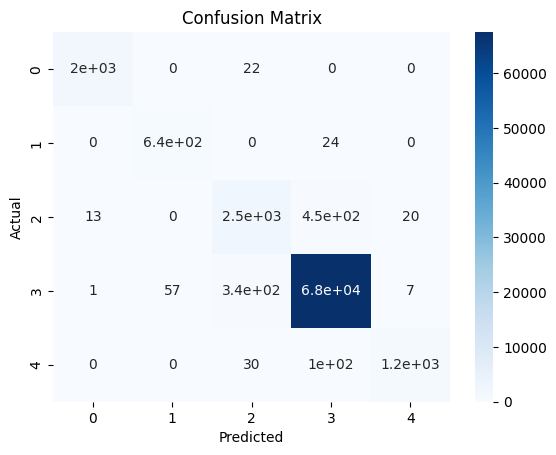

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Class 3 (Normal):
Excellent performance — 67,000+ correct predictions

Class 0 (Blackhole):
Often misclassified as Normal (420 times)
Still decently predicted (~1,400 correct)

Class 1 (Flooding):
Poor recall — many labeled as Normal (~290 misclassified)
Only 360 correctly predicted

Class 2 (Grayhole):
Mostly correct (~2,400 correct), but some confusion with Normal

Class 4 (TDMA):
High precision and recall — mostly predicted right (~1,200 correct)



Handle Class Imbalance

In [35]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_selected, y_train)

Applying KNN again

In [19]:
classifier.fit(X_resampled, y_resampled)
y_pred = classifier.predict(X_test_selected)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Accuracy: 0.9783139604713544
              precision    recall  f1-score   support

   Blackhole       0.99      0.99      0.99      2015
    Flooding       0.90      1.00      0.95       664
    Grayhole       0.69      0.97      0.81      2920
      Normal       1.00      0.98      0.99     68037
        TDMA       0.89      0.93      0.91      1297

    accuracy                           0.98     74933
   macro avg       0.89      0.97      0.93     74933
weighted avg       0.98      0.98      0.98     74933



After overfitting using SWOTE: accuracy decreased